In [4]:
!pip install wordcloud

In [7]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lingaraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lingaraj\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lingaraj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lingaraj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lingaraj\AppData\Roaming\nltk_data...


True

In [8]:
# Data Manipulation

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# NLP

import nltk
import re
import string

from wordcloud import WordCloud

# Ignore warnings

import warnings
warnings.filterwarnings("ignore")

# Display plots

%matplotlib inline

In [9]:
df = pd.read_csv("amazonreviews.tsv", sep='\t')

df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [10]:
print("Shape of Dataset :", df.shape)

Shape of Dataset : (10000, 2)


In [11]:
df.sample(5)

,label,review
226,neg,Don't waste your money: I ordered this because...
1332,pos,Very nice and handy to store: I got these as a...
8070,pos,My son loves this game!: I wanted to say that ...
7550,pos,Eight for the Money: If you are a fan of publi...
1641,neg,The characters seem unrealsitic and have a ver...


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [13]:
df.describe(include='all')

,label,review
count,10000,10000
unique,2,10000
top,neg,Stuning even for the non-gamer: This sound tra...
freq,5097,1


In [14]:
df.isnull().sum()

label     0
review    0
dtype: int64

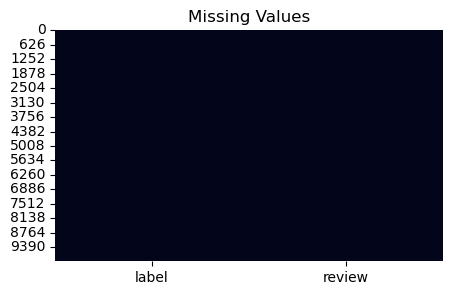

In [15]:
plt.figure(figsize=(5,3))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

In [16]:
print("Duplicate Reviews :", df.duplicated().sum())

Duplicate Reviews : 0


In [17]:
df = df.drop_duplicates()

print(df.shape)

(10000, 2)


In [18]:
df['label'].value_counts()

label
neg    5097
pos    4903
Name: count, dtype: int64

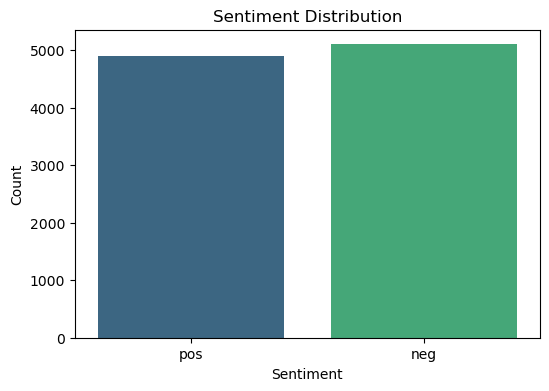

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='label',
    palette='viridis'
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

In [20]:
df['review_length'] = df['review'].apply(len)

df[['review','review_length']].head()

,review,review_length
0,Stuning even for the non-gamer: This sound tra...,426
1,The best soundtrack ever to anything.: I'm rea...,509
2,Amazing!: This soundtrack is my favorite music...,760
3,Excellent Soundtrack: I truly like this soundt...,743
4,"Remember, Pull Your Jaw Off The Floor After He...",481


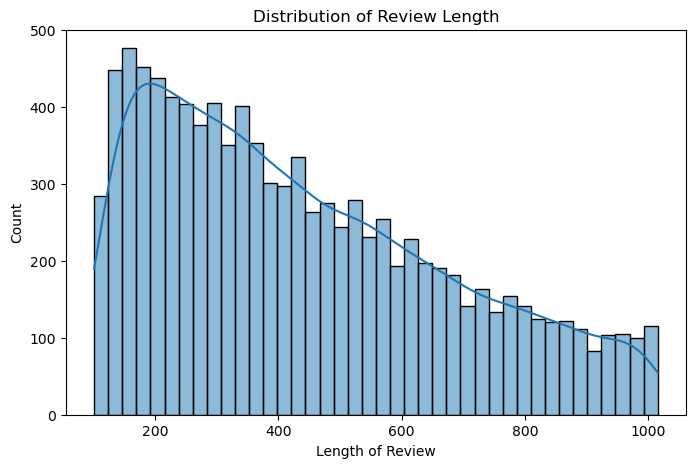

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['review_length'],
    bins=40,
    kde=True
)

plt.title("Distribution of Review Length")

plt.xlabel("Length of Review")

plt.show()

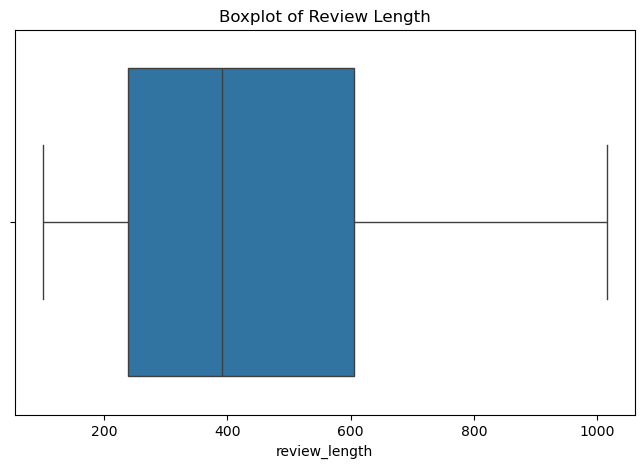

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['review_length']
)

plt.title("Boxplot of Review Length")

plt.show()

In [23]:
positive_reviews = df[df['label']=='pos']

negative_reviews = df[df['label']=='neg']

print("Positive Reviews :", positive_reviews.shape[0])

print("Negative Reviews :", negative_reviews.shape[0])

Positive Reviews : 4903
Negative Reviews : 5097


In [24]:
positive_reviews.head()

,label,review,review_length
0,pos,Stuning even for the non-gamer: This sound tra...,426
1,pos,The best soundtrack ever to anything.: I'm rea...,509
2,pos,Amazing!: This soundtrack is my favorite music...,760
3,pos,Excellent Soundtrack: I truly like this soundt...,743
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",481


In [25]:
negative_reviews.head()

,label,review,review_length
6,neg,"Buyer beware: This is a self-published book, a...",738
10,neg,The Worst!: A complete waste of time. Typograp...,216
13,neg,Oh please: I guess you have to be a romance no...,492
14,neg,Awful beyond belief!: I feel I have to write t...,692
15,neg,Don't try to fool us with fake reviews.: It's ...,304


In [26]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [27]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [28]:
def clean_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Tokenization
    tokens = text.split()

    # Stopword Removal
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [29]:
df['clean_review'] = df['review'].apply(clean_text)

df[['review','clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...


In [30]:
df['original_length'] = df['review'].apply(len)

df['clean_length'] = df['clean_review'].apply(len)

df[['original_length','clean_length']].head()

,original_length,clean_length
0,426,277
1,509,306
2,760,483
3,743,532
4,481,296


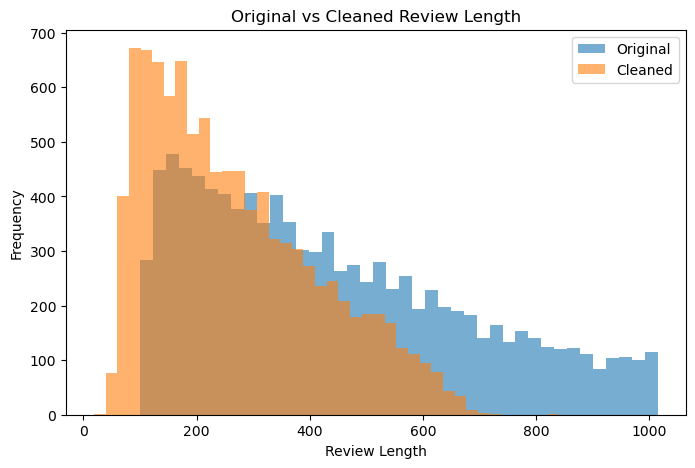

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df['original_length'],
         bins=40,
         alpha=0.6,
         label='Original')

plt.hist(df['clean_length'],
         bins=40,
         alpha=0.6,
         label='Cleaned')

plt.legend()

plt.title("Original vs Cleaned Review Length")

plt.xlabel("Review Length")

plt.ylabel("Frequency")

plt.show()

In [32]:
for i in range(5):

    print("="*80)

    print("Original Review:\n")

    print(df['review'][i])

    print("\n")

    print("Cleaned Review:\n")

    print(df['clean_review'][i])

    print("\n")

Original Review:

Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^


Cleaned Review:

stuning even non gamer sound track beautiful paint senery mind well would recomend even people hate vid game music played game chrono cross game ever played best music back away crude keyboarding take fresher step grate guitar soulful orchestra would impress anyone care listen


Original Review:

The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The

In [33]:
from collections import Counter

all_words = " ".join(df['clean_review'])

word_list = all_words.split()

word_freq = Counter(word_list)

word_freq.most_common(20)

[('book', 7693),
 ('one', 4190),
 ('movie', 3114),
 ('like', 2934),
 ('read', 2903),
 ('good', 2834),
 ('great', 2782),
 ('time', 2510),
 ('would', 2421),
 ('get', 2247),
 ('story', 1656),
 ('really', 1615),
 ('well', 1509),
 ('make', 1487),
 ('first', 1484),
 ('work', 1482),
 ('much', 1446),
 ('even', 1430),
 ('love', 1368),
 ('buy', 1279)]

In [34]:
common_words = pd.DataFrame(word_freq.most_common(20),
                            columns=['Word','Frequency'])

common_words

,Word,Frequency
0,book,7693
1,one,4190
2,movie,3114
3,like,2934
4,read,2903
5,good,2834
6,great,2782
7,time,2510
8,would,2421
9,get,2247


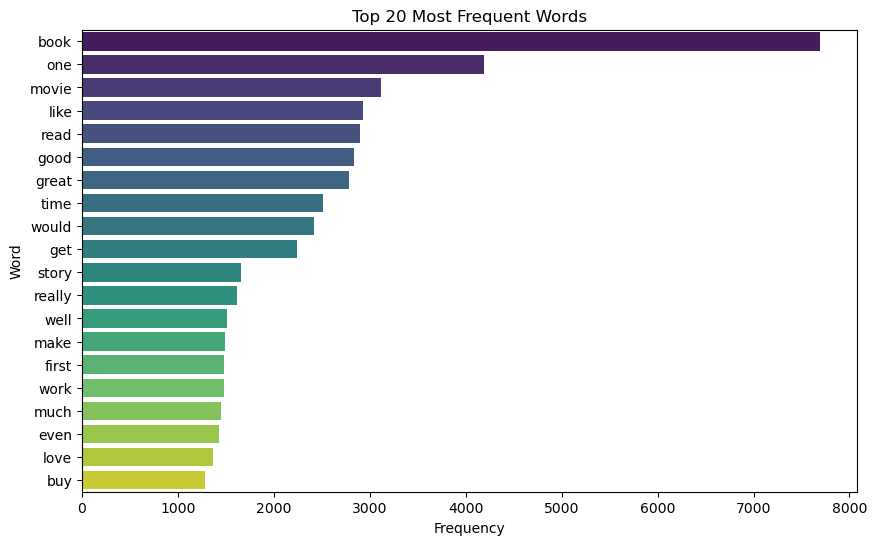

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(data=common_words,
            x='Frequency',
            y='Word',
            palette='viridis')

plt.title("Top 20 Most Frequent Words")

plt.show()

## Summary of Preprocessing

### The text preprocessing stage successfully cleaned the customer reviews by:

- Converting text to lowercase
- Removing HTML tags
- Removing URLs
- Removing punctuation
- Removing numbers
- Performing tokenization
- Removing stopwords
- Applying lemmatization

The cleaned text is now ready for feature extraction using TF-IDF and Word2Vec.

In [37]:
from wordcloud import WordCloud

from collections import Counter

In [38]:
positive_reviews = df[df['label'] == 'pos']['clean_review']

negative_reviews = df[df['label'] == 'neg']['clean_review']

print("Positive Reviews :", len(positive_reviews))
print("Negative Reviews :", len(negative_reviews))

Positive Reviews : 4903
Negative Reviews : 5097


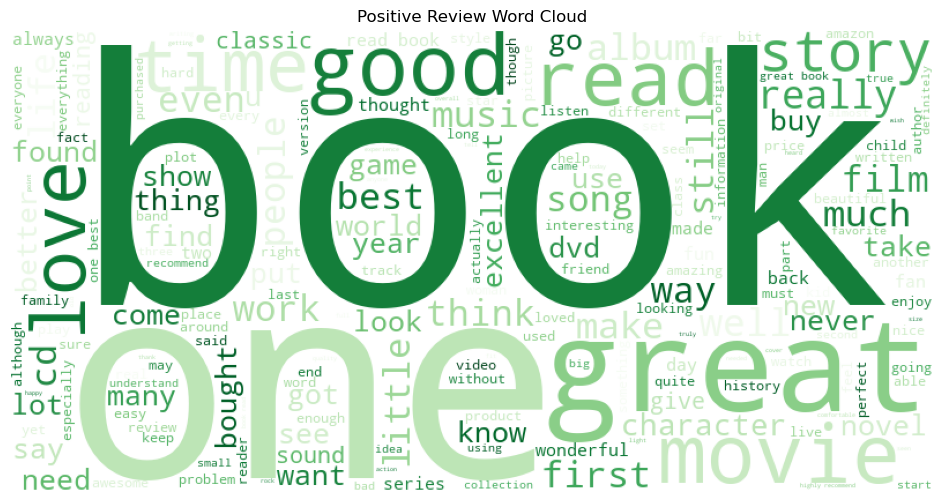

In [39]:
positive_text = " ".join(positive_reviews)

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud_positive)

plt.axis("off")

plt.title("Positive Review Word Cloud")

plt.show()

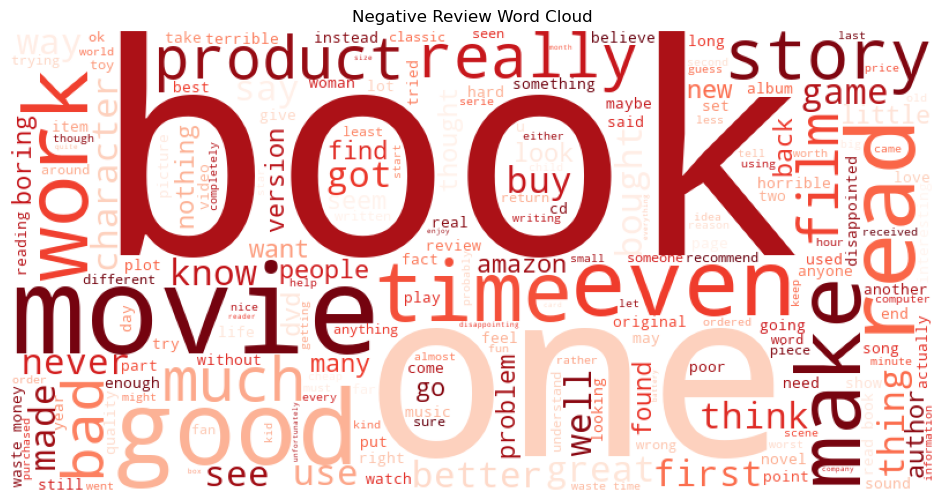

In [41]:
negative_text = " ".join(negative_reviews)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud_negative)

plt.axis("off")

plt.title("Negative Review Word Cloud")

plt.show()

In [42]:
positive_words = " ".join(positive_reviews).split()

positive_counter = Counter(positive_words)

top_positive = pd.DataFrame(
    positive_counter.most_common(20),
    columns=['Word','Frequency']
)

top_positive

,Word,Frequency
0,book,3933
1,great,2137
2,one,1997
3,good,1671
4,read,1628
5,like,1342
6,movie,1330
7,time,1189
8,love,1045
9,would,956


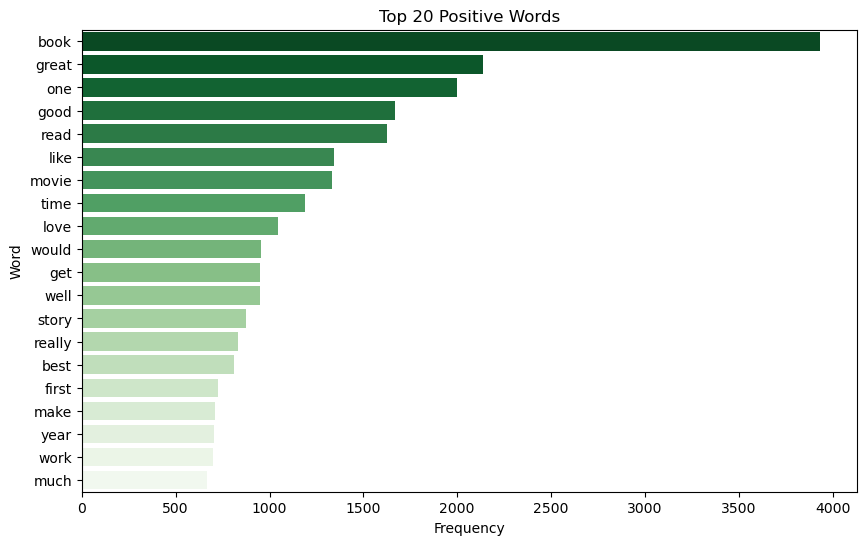

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_positive,
    x='Frequency',
    y='Word',
    palette='Greens_r'
)

plt.title("Top 20 Positive Words")

plt.show()

In [44]:
negative_words = " ".join(negative_reviews).split()

negative_counter = Counter(negative_words)

top_negative = pd.DataFrame(
    negative_counter.most_common(20),
    columns=['Word','Frequency']
)

top_negative

,Word,Frequency
0,book,3760
1,one,2193
2,movie,1784
3,like,1592
4,would,1465
5,time,1321
6,get,1299
7,read,1275
8,good,1163
9,even,910


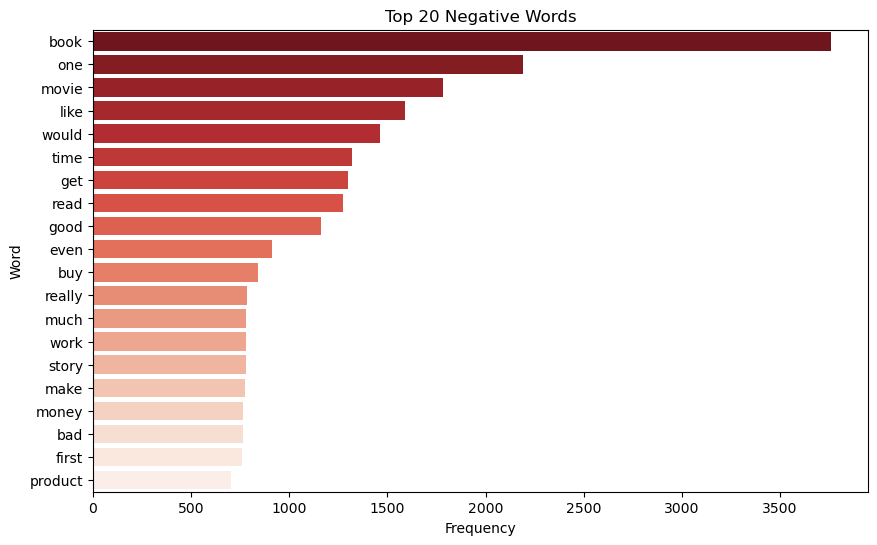

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_negative,
    x='Frequency',
    y='Word',
    palette='Reds_r'
)

plt.title("Top 20 Negative Words")

plt.show()

In [46]:
sentiment_count = df['label'].value_counts()

sentiment_count

label
neg    5097
pos    4903
Name: count, dtype: int64

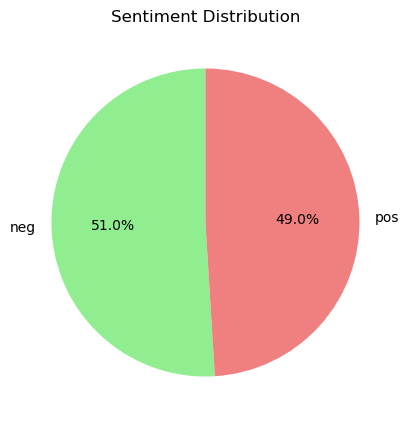

In [47]:
plt.figure(figsize=(6,5))

plt.pie(
    sentiment_count,
    labels=sentiment_count.index,
    autopct='%1.1f%%',
    colors=['lightgreen','lightcoral'],
    startangle=90
)

plt.title("Sentiment Distribution")

plt.show()

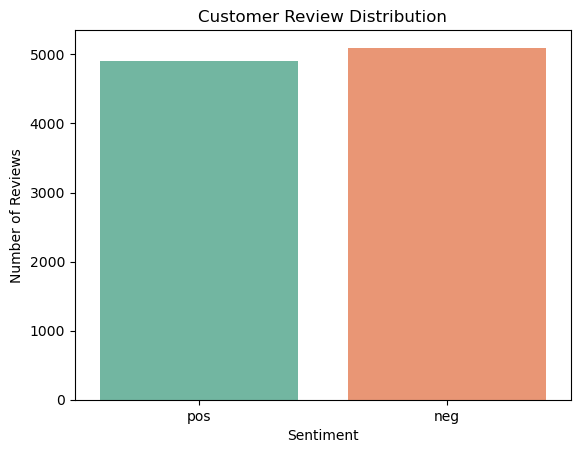

In [48]:
sns.countplot(
    data=df,
    x='label',
    palette='Set2'
)

plt.title("Customer Review Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

## Key Insights

- The dataset contains both positive and negative customer reviews.
- Positive reviews mainly include appreciation-related words.
- Negative reviews contain complaint-related words.
- The dataset is reasonably balanced, making it suitable for sentiment classification.
- The cleaned text is now ready for feature extraction using TF-IDF and Word2Vec.

## TF_DF + Lgistic Regression model

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.model_selection import cross_val_score

In [50]:
encoder = LabelEncoder()

df['label_encoded'] = encoder.fit_transform(df['label'])

df[['label','label_encoded']].head()

,label,label_encoded
0,pos,1
1,pos,1
2,pos,1
3,pos,1
4,pos,1


In [51]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])

y = df['label_encoded']

In [52]:
print("Shape of TF-IDF Matrix :", X.shape)

Shape of TF-IDF Matrix : (10000, 5000)


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [54]:
print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (8000, 5000)
Testing Samples : (2000, 5000)


In [55]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [56]:
y_pred = lr_model.predict(X_test)

In [57]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Accuracy : 0.8445
Precision : 0.8446502057613169
Recall : 0.836901121304791
F1 Score : 0.840757808499744


In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1019
           1       0.84      0.84      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [59]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[868, 151],
       [160, 821]])

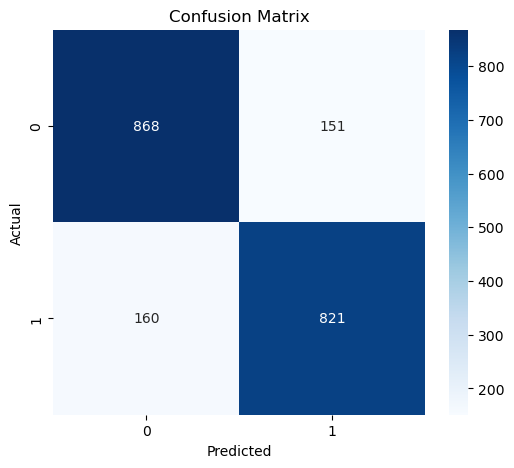

In [60]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [61]:
cv_scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

cv_scores

array([0.8565, 0.8255, 0.8195, 0.837 , 0.852 ])

In [62]:
print("Cross Validation Scores :")

print(cv_scores)

print()

print("Average Accuracy :")

print(cv_scores.mean())

Cross Validation Scores :
[0.8565 0.8255 0.8195 0.837  0.852 ]

Average Accuracy :
0.8381000000000001


In [63]:
feature_names = tfidf.get_feature_names_out()

coefficients = lr_model.coef_[0]

importance = pd.DataFrame({

    'Word': feature_names,

    'Coefficient': coefficients

})

importance.head()

,Word,Coefficient
0,aa,-0.147115
1,abandoned,-0.346384
2,abba,0.424669
3,ability,0.600154
4,able,0.325718


In [64]:
top_positive = importance.sort_values(
    by='Coefficient',
    ascending=False
).head(20)

top_negative = importance.sort_values(
    by='Coefficient'
).head(20)

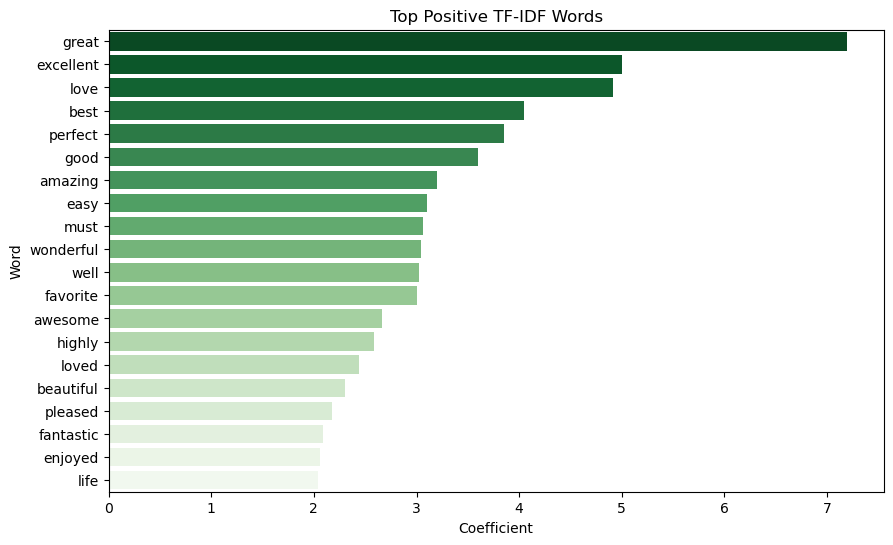

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_positive,
    x='Coefficient',
    y='Word',
    palette='Greens_r'
)

plt.title("Top Positive TF-IDF Words")

plt.show()

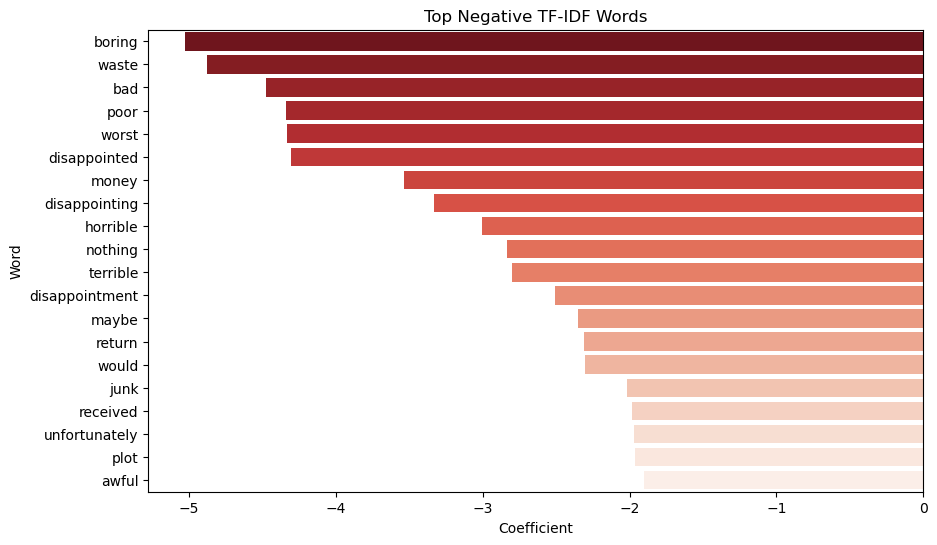

In [66]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_negative,
    x='Coefficient',
    y='Word',
    palette='Reds_r'
)

plt.title("Top Negative TF-IDF Words")

plt.show()

### Conclusion of TF-IDF Model

The Logistic Regression model was successfully trained using TF-IDF features.

The model achieved good Accuracy and F1-score, indicating that TF-IDF is effective for representing customer review text.

Cross-validation also showed consistent performance, demonstrating that the model generalizes well on unseen data.

In [67]:
!pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.4 MB 19.5 MB/s eta 0:00:02
   ---------- ----------------------------- 6.6/24.4 MB 22.5 MB/s eta 0:00:01
   ----------------- ---------------------- 10.5/24.4 MB 21.3 MB/s eta 0:00:01
   ------------------------ --------------- 15.2/24.4 MB 21.7 MB/s eta 0:00:01
   ------------------------------- -------- 19.1/24.4 MB 21.3 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 22.2 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 20.9 MB/s  0:00:01

   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ---------------

In [68]:
from gensim.models import Word2Vec
import numpy as np

In [69]:
tokenized_reviews = [review.split() for review in df['clean_review']]

tokenized_reviews[:3]

[['stuning',
  'even',
  'non',
  'gamer',
  'sound',
  'track',
  'beautiful',
  'paint',
  'senery',
  'mind',
  'well',
  'would',
  'recomend',
  'even',
  'people',
  'hate',
  'vid',
  'game',
  'music',
  'played',
  'game',
  'chrono',
  'cross',
  'game',
  'ever',
  'played',
  'best',
  'music',
  'back',
  'away',
  'crude',
  'keyboarding',
  'take',
  'fresher',
  'step',
  'grate',
  'guitar',
  'soulful',
  'orchestra',
  'would',
  'impress',
  'anyone',
  'care',
  'listen'],
 ['best',
  'soundtrack',
  'ever',
  'anything',
  'reading',
  'lot',
  'review',
  'saying',
  'best',
  'game',
  'soundtrack',
  'figured',
  'write',
  'review',
  'disagree',
  'bit',
  'opinino',
  'yasunori',
  'mitsuda',
  'ultimate',
  'masterpiece',
  'music',
  'timeless',
  'listening',
  'year',
  'beauty',
  'simply',
  'refuse',
  'fade',
  'price',
  'tag',
  'pretty',
  'staggering',
  'must',
  'say',
  'going',
  'buy',
  'cd',
  'much',
  'money',
  'one',
  'feel',
  'would

In [70]:
word2vec_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20,
    seed=42
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [71]:
print("Vocabulary Size :", len(word2vec_model.wv))

Vocabulary Size : 14423


In [72]:
def document_vector(words):

    vectors = []

    for word in words:

        if word in word2vec_model.wv:

            vectors.append(word2vec_model.wv[word])

    if len(vectors) == 0:

        return np.zeros(100)

    return np.mean(vectors, axis=0)

In [73]:
X_word2vec = np.array(
    [document_vector(review) for review in tokenized_reviews]
)

X_word2vec.shape

(10000, 100)

In [74]:
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_word2vec,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [75]:
lr_word2vec = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_word2vec.fit(X_train_w2v, y_train_w2v)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [76]:
## prediction
y_pred_w2v = lr_word2vec.predict(X_test_w2v)

In [77]:
word2vec_accuracy = accuracy_score(
    y_test_w2v,
    y_pred_w2v
)

word2vec_precision = precision_score(
    y_test_w2v,
    y_pred_w2v
)

word2vec_recall = recall_score(
    y_test_w2v,
    y_pred_w2v
)

word2vec_f1 = f1_score(
    y_test_w2v,
    y_pred_w2v
)

print("Accuracy :", word2vec_accuracy)

print("Precision :", word2vec_precision)

print("Recall :", word2vec_recall)

print("F1 Score :", word2vec_f1)

Accuracy : 0.8205
Precision : 0.8141414141414142
Recall : 0.8216106014271152
F1 Score : 0.8178589548452562


In [78]:
print(classification_report(
    y_test_w2v,
    y_pred_w2v
))

              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1019
           1       0.81      0.82      0.82       981

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



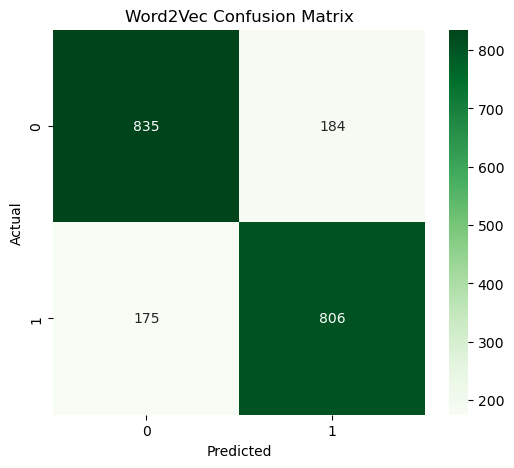

In [79]:
cm_w2v = confusion_matrix(
    y_test_w2v,
    y_pred_w2v
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_w2v,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Word2Vec Confusion Matrix")

plt.show()

In [80]:
cv_scores_w2v = cross_val_score(
    lr_word2vec,
    X_word2vec,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores")

print(cv_scores_w2v)

print()

print("Average Accuracy")

print(cv_scores_w2v.mean())

Cross Validation Scores
[0.8385 0.8255 0.8205 0.825  0.834 ]

Average Accuracy
0.8286999999999999


In [81]:
comparison = pd.DataFrame({

    "Embedding Technique":[
        "TF-IDF",
        "Word2Vec"
    ],

    "Accuracy":[
        accuracy,
        word2vec_accuracy
    ],

    "Precision":[
        precision,
        word2vec_precision
    ],

    "Recall":[
        recall,
        word2vec_recall
    ],

    "F1 Score":[
        f1,
        word2vec_f1
    ]

})

comparison

,Embedding Technique,Accuracy,Precision,Recall,F1 Score
0,TF-IDF,0.8445,0.844650,0.836901,0.840758
1,Word2Vec,0.8205,0.814141,0.821611,0.817859


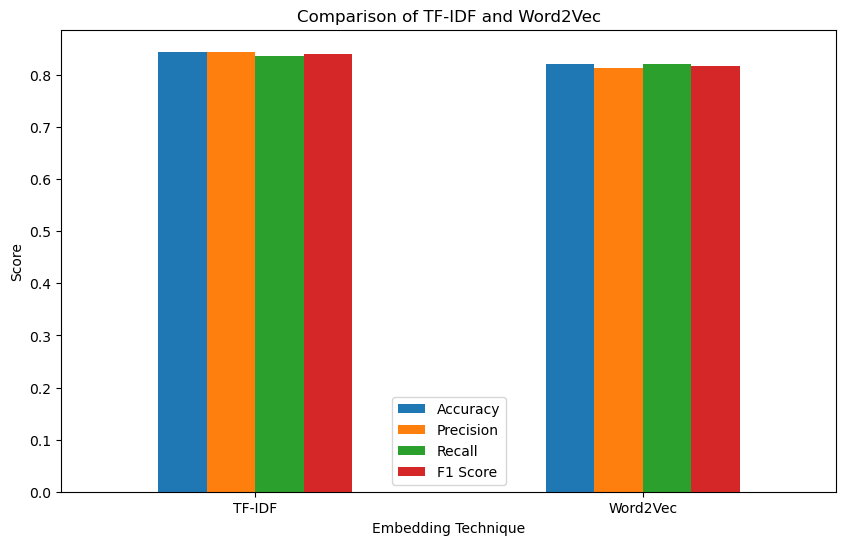

In [82]:
comparison.set_index("Embedding Technique").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of TF-IDF and Word2Vec")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

### Observations

- TF-IDF represents text based on word importance.
- Word2Vec captures semantic relationships between words.
- Both models were evaluated using Accuracy, Precision, Recall, and F1-score.
- The comparison helps identify which embedding technique performs better on customer review sentiment classification.

## ROC Curve, Business Insights and Final Conclusion

In [84]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [85]:
y_prob = lr_model.predict_proba(X_test)[:,1]

In [86]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score :", auc_score)

ROC-AUC Score : 0.9233273211629398


In [87]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score :", auc_score)

ROC-AUC Score : 0.9233273211629398


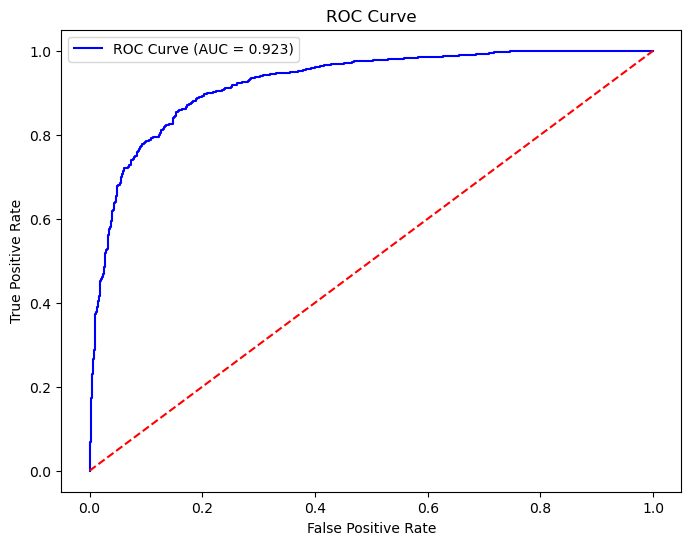

In [88]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.3f})",
    color="blue"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [89]:
comparison

,Embedding Technique,Accuracy,Precision,Recall,F1 Score
0,TF-IDF,0.8445,0.844650,0.836901,0.840758
1,Word2Vec,0.8205,0.814141,0.821611,0.817859


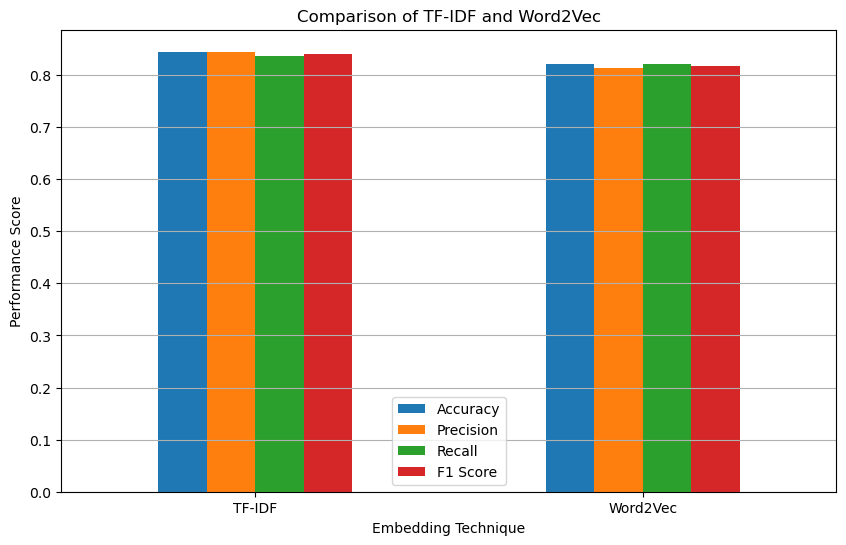

In [90]:
comparison.set_index("Embedding Technique").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of TF-IDF and Word2Vec")

plt.ylabel("Performance Score")

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()

In [91]:
comparison.to_csv("Embedding_Comparison.csv", index=False)

print("Comparison table saved successfully.")

Comparison table saved successfully.


In [92]:
import pickle

with open("tfidf_logistic_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Model and Vectorizer saved successfully.")

Model and Vectorizer saved successfully.
